In [1]:
import re
from pathlib import Path

import rootutils

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf
from PIL import Image

from hydra.utils import instantiate

from src.inference import load_model_and_transform
from src.viaABC.systems import Spatial2D

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# -----------------------------
# 1. Configuration
# -----------------------------
PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))

# HPC run path configuration. The latest completed inference is selected below.
RUN_ROOT = Path("/insomnia001/depts/iicd/users/kz2537/viaABC/run")
TRAIN_RUN_BASE = RUN_ROOT / "train" / "spatial2D"
RUN_FOLDER_PATH = TRAIN_RUN_BASE / "2026-06-03_11-34-14_bs10_acc2_nw2"
CHECKPOINT_SUBSTR = "last"
INFERENCE_OUTPUT_ROOT = RUN_FOLDER_PATH / "inference_output"

# Set this to a concrete inference directory to override auto-selection.
MANUAL_INFERENCE_RUN_DIR = None


def _log_completed(log_path):
    if not log_path.exists():
        return False
    return "Inference completed successfully" in log_path.read_text(errors="ignore")


def _latest_inference_dir(output_root, *, require_completed=True, require_generations=False):
    output_root = Path(output_root)
    candidates = []
    if not output_root.exists():
        return None

    for path in output_root.iterdir():
        if not path.is_dir():
            continue
        log_path = path / "inference.log"
        if not log_path.exists():
            continue
        if require_completed and not _log_completed(log_path):
            continue
        if require_generations and not (path / "abc_generations.npy").exists():
            continue
        candidates.append(path)

    if not candidates:
        return None
    return max(candidates, key=lambda path: (path / "inference.log").stat().st_mtime)


INFERENCE_RUN_DIR = (
    Path(MANUAL_INFERENCE_RUN_DIR).expanduser()
    if MANUAL_INFERENCE_RUN_DIR is not None
    else _latest_inference_dir(INFERENCE_OUTPUT_ROOT, require_completed=True, require_generations=True)
)
if INFERENCE_RUN_DIR is None:
    INFERENCE_RUN_DIR = _latest_inference_dir(INFERENCE_OUTPUT_ROOT, require_completed=True, require_generations=False)
if INFERENCE_RUN_DIR is None:
    raise FileNotFoundError(f"No completed inference output found under {INFERENCE_OUTPUT_ROOT}")

LATEST_INFERENCE_RUN_DIR = _latest_inference_dir(INFERENCE_OUTPUT_ROOT, require_completed=False, require_generations=False)
POSTERIOR_NPY_PATH = INFERENCE_RUN_DIR / "abc_generations.npy"
RECONSTRUCTION_PATH = INFERENCE_RUN_DIR / "reconstruction.png"
INFERENCE_LOG_PATH = INFERENCE_RUN_DIR / "inference.log"

def matching_resource_usage_path(output_root, inference_log_path):
    candidates = sorted(Path(output_root).glob("resource_usage_*.csv"))
    if not candidates or not inference_log_path.exists():
        return None
    log_mtime = inference_log_path.stat().st_mtime
    before_or_near = [p for p in candidates if p.stat().st_mtime <= log_mtime + 120]
    candidates = before_or_near or candidates
    return min(candidates, key=lambda p: abs(p.stat().st_mtime - log_mtime))


RESOURCE_USAGE_PATH = matching_resource_usage_path(INFERENCE_OUTPUT_ROOT, INFERENCE_LOG_PATH)

TRAIN_CFG_PATH = RUN_FOLDER_PATH / ".hydra" / "config.yaml"
TRAIN_CFG = OmegaConf.load(TRAIN_CFG_PATH)
BASE_SYSTEM_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "system" / "spatial2D.yaml")
TRAIN_MODEL_NUM_FRAMES = int(TRAIN_CFG.model.net.get("num_frames", 1))


def add_temporal_observation_paths(observation_samples):
    samples = OmegaConf.to_container(observation_samples, resolve=True)
    if not TRAIN_CFG.data.datamodule.dataset.get("temporal", False) or TRAIN_MODEL_NUM_FRAMES <= 1:
        return OmegaConf.create(samples)

    candidate_roots = [
        Path(TRAIN_CFG.data.datamodule.data_dir),
        PROJECT_ROOT / "data" / "spatial2D",
    ]
    for sample_name, sample_cfg in samples.items():
        if sample_cfg.get("temporal_observation") is not None:
            continue
        temporal_name = f"{sample_name}_t{TRAIN_MODEL_NUM_FRAMES}_true_theta.npy"
        for root in candidate_roots:
            temporal_path = root / "observation_paths" / temporal_name
            if temporal_path.exists():
                sample_cfg["temporal_observation"] = str(temporal_path)
                break
    return OmegaConf.create(samples)


def first_sample_id(sample_value):
    sample_value = OmegaConf.to_container(sample_value, resolve=True)
    if isinstance(sample_value, (list, tuple)):
        return sample_value[0]
    return sample_value


TRAIN_SYSTEM_CFG = OmegaConf.create(OmegaConf.to_container(BASE_SYSTEM_CFG.system, resolve=False))
TRAIN_OBSERVATION_SAMPLES = add_temporal_observation_paths(TRAIN_CFG.data.observation_samples)
TRAIN_SYSTEM_CFG.observation_samples = TRAIN_OBSERVATION_SAMPLES
TRAIN_SYSTEM_CFG.sample_id = TRAIN_CFG.data.get("observation_sample", "sample_1")
TRAIN_SYSTEM_CFG.use_time_series = TRAIN_CFG.data.datamodule.dataset.get("temporal", TRAIN_SYSTEM_CFG.get("use_time_series", True))
SAMPLE_ID = first_sample_id(TRAIN_CFG.data.get("observation_sample", "sample_1"))

# Keep the inference tiny but still numerically valid for ad hoc debugging cells.
ABC_DEBUG_CFG = {
    "num_particles": 10,
    "k": 10,
    "q_threshold": 0.90,
    "max_generations": 1,
    "num_workers": 10,
    "simulation_batch_size": 1,
    "max_pending_simulations": 1,
}

if ABC_DEBUG_CFG["num_particles"] < 2:
    raise ValueError("Please keep num_particles >= 2 for debugging.")

BASE_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference.yaml")
SPATIAL2D_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference" / "spatial2D.yaml")
DATA_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "data" / "spatial2D.yaml")
INFERENCE_CFG = OmegaConf.merge(BASE_INFERENCE_CFG, SPATIAL2D_INFERENCE_CFG)
INFERENCE_CFG.data = DATA_CFG

PARAM_NAMES = ["alpha", "beta", "gamma"][: int(TRAIN_CFG.system.get("num_parameters", 2))]
STATE_CMAP = ListedColormap([
    "#d73027",
    "#fee08b",
    "#4575b4",
    "#2b1744",
    "#1a9850",
    "#d9d9d9",
])

print("RUN_FOLDER_PATH:", RUN_FOLDER_PATH)
print("TRAIN_CFG_PATH:", TRAIN_CFG_PATH)
print("selected completed inference:", INFERENCE_RUN_DIR)
print("latest inference dir:", LATEST_INFERENCE_RUN_DIR)
print("posterior npy:", POSTERIOR_NPY_PATH if POSTERIOR_NPY_PATH.exists() else "missing")
print("reconstruction:", RECONSTRUCTION_PATH if RECONSTRUCTION_PATH.exists() else "missing")
print("SAMPLE_ID:", SAMPLE_ID)
print("PARAM_NAMES:", PARAM_NAMES)
print("ABC_DEBUG_CFG:", ABC_DEBUG_CFG)


RUN_FOLDER_PATH: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2
TRAIN_CFG_PATH: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/.hydra/config.yaml
selected completed inference: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436
latest inference dir: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-09_20-21-41_e69b7bb8
posterior npy: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436/abc_generations.npy
reconstruction: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436/reconstruction.png
SAMPLE_ID: sample_1
PARAM_NAMES: ['alpha', 'beta']
ABC

In [3]:
# -----------------------------
# 2. Minimal helper logic
# -----------------------------
sample_cfg = OmegaConf.to_container(TRAIN_OBSERVATION_SAMPLES[SAMPLE_ID], resolve=True)


def resolve_sample_path(path_value):
    path = Path(str(path_value).replace("${paths.data_dir}", str(TRAIN_CFG.paths.data_dir)))
    return path if path.is_absolute() else PROJECT_ROOT / path


txt_path = resolve_sample_path(sample_cfg["txt"])

image_candidates = []
if sample_cfg.get("image") is not None:
    image_candidates.append(resolve_sample_path(sample_cfg["image"]))

match = re.search(r"(\d+)$", SAMPLE_ID)
if match is not None:
    idx = match.group(1)
    image_candidates.extend([
        PROJECT_ROOT / "data" / "spatial2D" / f"img{idx}.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}_processed.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}.jpg",
    ])

raw_image_path = next((path for path in image_candidates if path.exists()), None)


def final_label_frame(grid):
    grid = np.asarray(grid)
    return grid[-1] if grid.ndim == 3 else grid


def draw_grid(ax, grid, title):
    grid = final_label_frame(grid)
    ax.imshow(grid, cmap=STATE_CMAP, vmin=0, vmax=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def weighted_quantile(values, quantile, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return np.interp(quantile, cumulative, values)


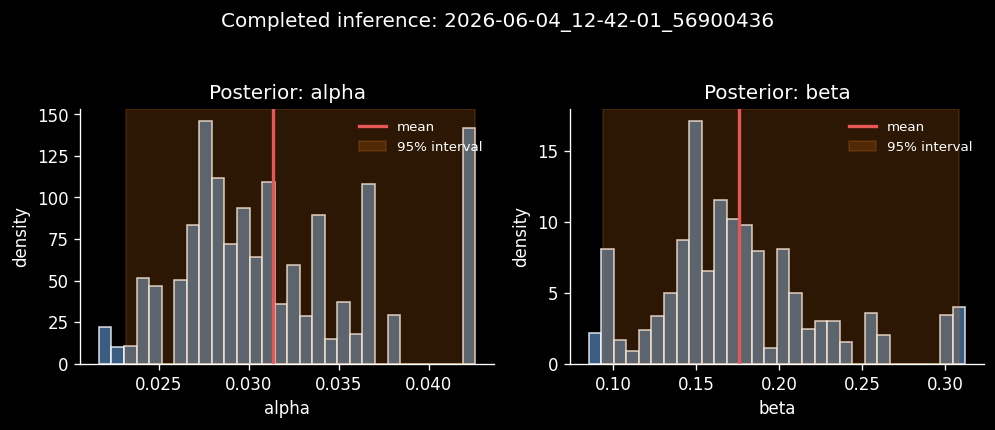

posterior npy: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436/abc_generations.npy
generation: 19
particles shape: (100, 2)
epsilon: 0.015688404
simulations: 37016
qt: 0.47102177300233233

Posterior summary
   alpha: mean=0.0313181, median=0.0302093, 95%=[0.0231561, 0.0425816]
    beta: mean=0.175478, median=0.166317, 95%=[0.0937313, 0.308069]


In [4]:
# -----------------------------
# 3. Plot posterior histograms from the selected completed inference output
# -----------------------------
def load_generations(path):
    path = Path(path).expanduser()
    loaded = np.load(path, allow_pickle=True)

    if isinstance(loaded, np.lib.npyio.NpzFile):
        loaded = loaded["generations"] if "generations" in loaded else loaded[loaded.files[0]]

    if isinstance(loaded, np.ndarray) and loaded.shape == ():
        loaded = loaded.item()
    elif isinstance(loaded, np.ndarray) and loaded.dtype == object:
        loaded = loaded.tolist()

    if isinstance(loaded, dict) and "generations" in loaded:
        loaded = loaded["generations"]

    return loaded


if not POSTERIOR_NPY_PATH.exists():
    raise FileNotFoundError(
        f"The selected completed output has no abc_generations.npy: {INFERENCE_RUN_DIR}. "
        "Set MANUAL_INFERENCE_RUN_DIR to a completed run with posterior output."
    )

generations = load_generations(POSTERIOR_NPY_PATH)
last_generation = generations[-1] if isinstance(generations, (list, tuple)) else generations

particles = np.asarray(last_generation["particles"], dtype=float)
weights = np.asarray(last_generation.get("weights", np.ones(len(particles))), dtype=float)
weights = weights / weights.sum()

if particles.ndim == 1:
    particles = particles[:, None]

param_names = PARAM_NAMES[: particles.shape[1]]
if len(param_names) < particles.shape[1]:
    param_names = param_names + [f"theta_{i}" for i in range(len(param_names), particles.shape[1])]

fig, axes = plt.subplots(1, particles.shape[1], figsize=(4.2 * particles.shape[1], 3.4), squeeze=False)
axes = axes.ravel()

summary_rows = []
for i, (ax, name) in enumerate(zip(axes, param_names)):
    values = particles[:, i]
    mean = np.average(values, weights=weights)
    q025 = weighted_quantile(values, 0.025, weights)
    q500 = weighted_quantile(values, 0.500, weights)
    q975 = weighted_quantile(values, 0.975, weights)
    summary_rows.append((name, mean, q500, q025, q975))

    ax.hist(values, bins=30, weights=weights, density=True, color="#4C78A8", alpha=0.78, edgecolor="white")
    ax.axvline(mean, color="#E45756", lw=2, label="mean")
    ax.axvspan(q025, q975, color="#F58518", alpha=0.18, label="95% interval")
    ax.set_title(f"Posterior: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(f"Completed inference: {INFERENCE_RUN_DIR.name}", y=1.04)
fig.tight_layout()
plt.show()

print("posterior npy:", POSTERIOR_NPY_PATH)
print("generation:", last_generation.get("t", len(generations) - 1 if isinstance(generations, (list, tuple)) else "unknown"))
print("particles shape:", particles.shape)
print("epsilon:", last_generation.get("epsilon", None))
print("simulations:", last_generation.get("simulations", None))
print("qt:", last_generation.get("qt", None))
print("\nPosterior summary")
for name, mean, median, q025, q975 in summary_rows:
    print(f"{name:>8s}: mean={mean:.6g}, median={median:.6g}, 95%=[{q025:.6g}, {q975:.6g}]")


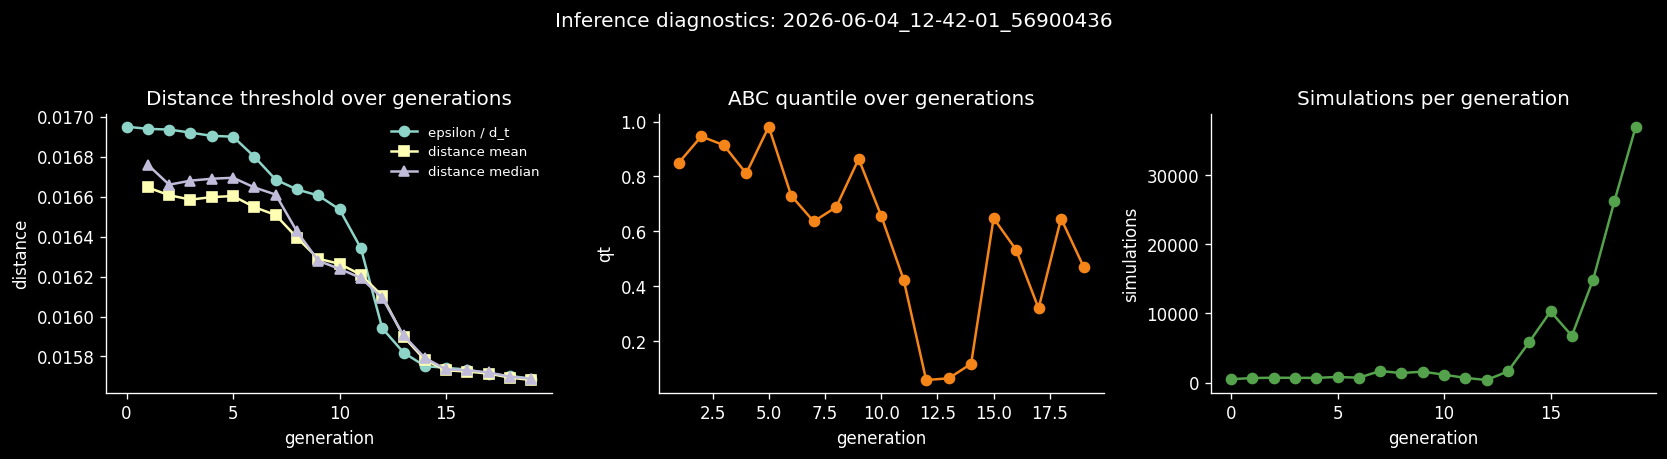

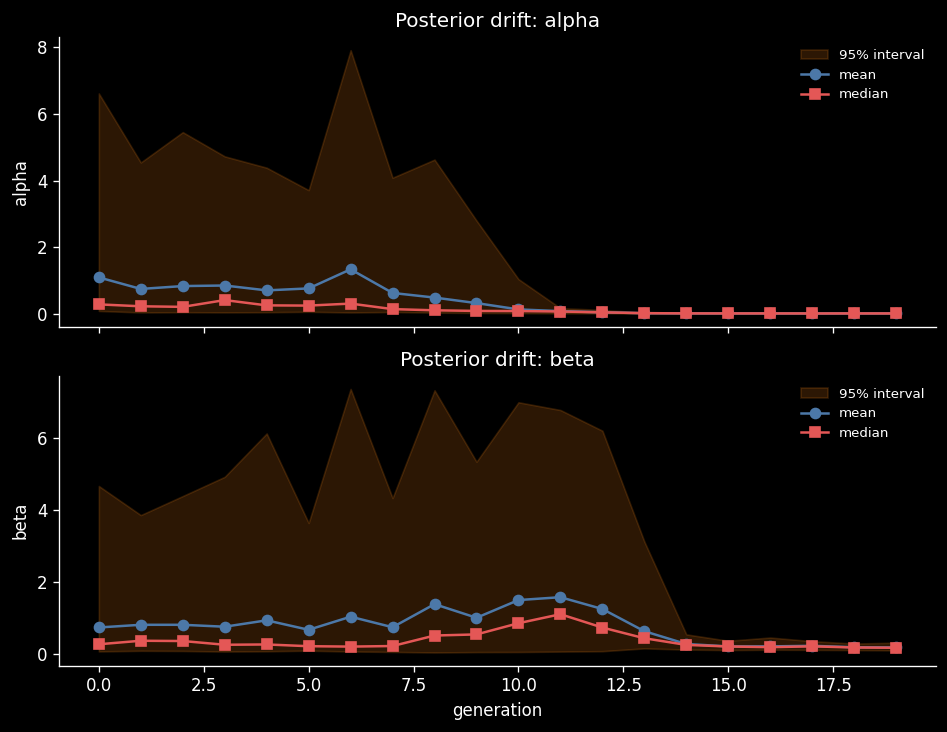

Posterior change between consecutive generations
generation_pair  param   mean_delta  median_delta  interval_overlap  meaningful
-------------------------------------------------------------------------------
         00->01  alpha   -0.344993    -0.0569653             0.683        True
         00->01   beta   0.0746926     0.0975686             0.820       False
         01->02  alpha    0.085773    -0.0171439             0.832       False
         01->02   beta  -0.000427925   -0.00750802             0.876       False
         02->03  alpha   0.0165525      0.202459             0.866       False
         02->03   beta  -0.0532326     -0.103545             0.887       False
         03->04  alpha   -0.145168     -0.158152             0.926       False
         03->04   beta    0.177396    0.00804473             0.801       False
         04->05  alpha    0.058557   -0.00654213             0.842       False
         04->05   beta   -0.262576    -0.0482794             0.586        True

In [5]:
# -----------------------------
# 4. Distance threshold and posterior drift over generations
# -----------------------------
def posterior_stats_by_generation(generations, param_names):
    rows = []
    for idx, gen in enumerate(generations):
        gen_id = int(gen.get("t", idx))
        particles = np.asarray(gen["particles"], dtype=float)
        weights = np.asarray(gen.get("weights", np.ones(len(particles))), dtype=float)
        weights = weights / weights.sum()
        if particles.ndim == 1:
            particles = particles[:, None]

        distances = gen.get("distances")
        distances = None if distances is None else np.asarray(distances, dtype=float)
        row = {
            "generation": gen_id,
            "epsilon": float(gen.get("epsilon", np.nan)),
            "qt": gen.get("qt", np.nan),
            "simulations": gen.get("simulations", np.nan),
            "distance_mean": np.nan if distances is None else float(np.mean(distances)),
            "distance_median": np.nan if distances is None else float(np.median(distances)),
            "distance_q025": np.nan if distances is None else float(np.quantile(distances, 0.025)),
            "distance_q975": np.nan if distances is None else float(np.quantile(distances, 0.975)),
            "params": {},
        }

        names = param_names[: particles.shape[1]]
        if len(names) < particles.shape[1]:
            names = names + [f"theta_{i}" for i in range(len(names), particles.shape[1])]

        for param_idx, name in enumerate(names):
            values = particles[:, param_idx]
            row["params"][name] = {
                "mean": float(np.average(values, weights=weights)),
                "median": float(weighted_quantile(values, 0.50, weights)),
                "q025": float(weighted_quantile(values, 0.025, weights)),
                "q975": float(weighted_quantile(values, 0.975, weights)),
            }
        rows.append(row)
    return rows


def interval_overlap_fraction(a_low, a_high, b_low, b_high):
    overlap = max(0.0, min(a_high, b_high) - max(a_low, b_low))
    denom = max(a_high - a_low, b_high - b_low, np.finfo(float).eps)
    return overlap / denom


stats_rows = posterior_stats_by_generation(generations, param_names)
gens = np.array([row["generation"] for row in stats_rows])
epsilons = np.array([row["epsilon"] for row in stats_rows])
distance_means = np.array([row["distance_mean"] for row in stats_rows])
distance_medians = np.array([row["distance_median"] for row in stats_rows])
qts = np.array([row["qt"] if row["qt"] is not None else np.nan for row in stats_rows], dtype=float)
simulations = np.array([row["simulations"] for row in stats_rows], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(gens, epsilons, marker="o", label="epsilon / d_t")
axes[0].plot(gens, distance_means, marker="s", label="distance mean")
axes[0].plot(gens, distance_medians, marker="^", label="distance median")
axes[0].set_title("Distance threshold over generations")
axes[0].set_xlabel("generation")
axes[0].set_ylabel("distance")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(gens, qts, marker="o", color="#F58518")
axes[1].set_title("ABC quantile over generations")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("qt")

axes[2].plot(gens, simulations, marker="o", color="#54A24B")
axes[2].set_title("Simulations per generation")
axes[2].set_xlabel("generation")
axes[2].set_ylabel("simulations")

fig.suptitle(f"Inference diagnostics: {INFERENCE_RUN_DIR.name}", y=1.05)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(len(param_names), 1, figsize=(8, 3.1 * len(param_names)), squeeze=False, sharex=True)
for ax, name in zip(axes.ravel(), param_names):
    means = np.array([row["params"][name]["mean"] for row in stats_rows])
    medians = np.array([row["params"][name]["median"] for row in stats_rows])
    lows = np.array([row["params"][name]["q025"] for row in stats_rows])
    highs = np.array([row["params"][name]["q975"] for row in stats_rows])

    ax.fill_between(gens, lows, highs, color="#F58518", alpha=0.18, label="95% interval")
    ax.plot(gens, means, marker="o", color="#4C78A8", label="mean")
    ax.plot(gens, medians, marker="s", color="#E45756", label="median")
    ax.set_title(f"Posterior drift: {name}")
    ax.set_ylabel(name)
    ax.legend(frameon=False, fontsize=8)
axes[-1, 0].set_xlabel("generation")
fig.tight_layout()
plt.show()

print("Posterior change between consecutive generations")
header = "generation_pair  param   mean_delta  median_delta  interval_overlap  meaningful"
print(header)
print("-" * len(header))

MEANINGFUL_MEAN_FRACTION = 0.10
MEANINGFUL_MEDIAN_FRACTION = 0.10
MEANINGFUL_OVERLAP_CUTOFF = 0.80
meaningful_rows = []
for prev, curr in zip(stats_rows[:-1], stats_rows[1:]):
    pair = f"{prev['generation']:02d}->{curr['generation']:02d}"
    for name in param_names:
        prev_stats = prev["params"][name]
        curr_stats = curr["params"][name]
        prev_width = max(prev_stats["q975"] - prev_stats["q025"], np.finfo(float).eps)
        curr_width = max(curr_stats["q975"] - curr_stats["q025"], np.finfo(float).eps)
        scale = max(prev_width, curr_width)
        mean_delta = curr_stats["mean"] - prev_stats["mean"]
        median_delta = curr_stats["median"] - prev_stats["median"]
        overlap = interval_overlap_fraction(
            prev_stats["q025"], prev_stats["q975"], curr_stats["q025"], curr_stats["q975"]
        )
        meaningful = (
            abs(mean_delta) > MEANINGFUL_MEAN_FRACTION * scale
            or abs(median_delta) > MEANINGFUL_MEDIAN_FRACTION * scale
            or overlap < MEANINGFUL_OVERLAP_CUTOFF
        )
        meaningful_rows.append(meaningful)
        print(
            f"{pair:>15s}  {name:>5s}  {mean_delta:>10.6g}  "
            f"{median_delta:>12.6g}  {overlap:>16.3f}  {str(meaningful):>10s}"
        )

last_pair_has_change = any(meaningful_rows[-len(param_names):]) if meaningful_rows else False
print("\nMeaningful-change heuristic:")
print(f"mean/median delta > {MEANINGFUL_MEAN_FRACTION:.0%} of the wider 95% interval, or interval overlap < {MEANINGFUL_OVERLAP_CUTOFF:.0%}.")
print("Last generation pair changes meaningfully:", last_pair_has_change)
if last_pair_has_change:
    print("Interpretation: posterior is still moving at the current d_t, so the distance thresholds remain informative/valid.")
else:
    print("Interpretation: posterior changes are small by this heuristic; d_t may be near a stable posterior regime.")


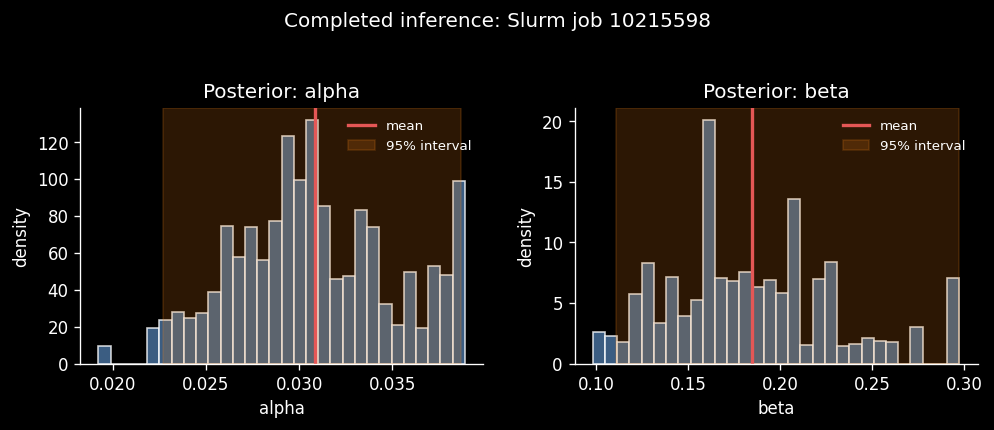

Slurm job: 10215598
inference dir: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-50-19_edc2a131
posterior npy: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-50-19_edc2a131/abc_generations.npy
generation: 19
particles shape: (100, 2)
epsilon: 0.015699133
simulations: 29592
qt: 0.5151193455956041

Posterior summary
   alpha: mean=0.0308412, median=0.0304836, 95%=[0.0226868, 0.0386672]
    beta: mean=0.184447, median=0.178566, 95%=[0.110567, 0.297145]


In [6]:
# -----------------------------
# 5. Plot posterior histograms from Slurm job 10215598
# -----------------------------
JOB_10215598_INFERENCE_RUN_DIR = (
    RUN_FOLDER_PATH / "inference_output" / "2026-06-04_12-50-19_edc2a131"
)
JOB_10215598_POSTERIOR_NPY_PATH = JOB_10215598_INFERENCE_RUN_DIR / "abc_generations.npy"

if not JOB_10215598_POSTERIOR_NPY_PATH.exists():
    raise FileNotFoundError(f"Expected posterior output not found: {JOB_10215598_POSTERIOR_NPY_PATH}")

generations_10215598 = load_generations(JOB_10215598_POSTERIOR_NPY_PATH)
last_generation_10215598 = generations_10215598[-1]

particles_10215598 = np.asarray(last_generation_10215598["particles"], dtype=float)
weights_10215598 = np.asarray(
    last_generation_10215598.get("weights", np.ones(len(particles_10215598))), dtype=float
)
weights_10215598 = weights_10215598 / weights_10215598.sum()

if particles_10215598.ndim == 1:
    particles_10215598 = particles_10215598[:, None]

param_names_10215598 = PARAM_NAMES[: particles_10215598.shape[1]]
if len(param_names_10215598) < particles_10215598.shape[1]:
    param_names_10215598 = param_names_10215598 + [
        f"theta_{i}" for i in range(len(param_names_10215598), particles_10215598.shape[1])
    ]

fig, axes = plt.subplots(
    1,
    particles_10215598.shape[1],
    figsize=(4.2 * particles_10215598.shape[1], 3.4),
    squeeze=False,
)
axes = axes.ravel()

summary_rows_10215598 = []
for i, (ax, name) in enumerate(zip(axes, param_names_10215598)):
    values = particles_10215598[:, i]
    mean = np.average(values, weights=weights_10215598)
    q025 = weighted_quantile(values, 0.025, weights_10215598)
    q500 = weighted_quantile(values, 0.500, weights_10215598)
    q975 = weighted_quantile(values, 0.975, weights_10215598)
    summary_rows_10215598.append((name, mean, q500, q025, q975))

    ax.hist(values, bins=30, weights=weights_10215598, density=True, color="#4C78A8", alpha=0.78, edgecolor="white")
    ax.axvline(mean, color="#E45756", lw=2, label="mean")
    ax.axvspan(q025, q975, color="#F58518", alpha=0.18, label="95% interval")
    ax.set_title(f"Posterior: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Completed inference: Slurm job 10215598", y=1.04)
fig.tight_layout()
plt.show()

print("Slurm job: 10215598")
print("inference dir:", JOB_10215598_INFERENCE_RUN_DIR)
print("posterior npy:", JOB_10215598_POSTERIOR_NPY_PATH)
print("generation:", last_generation_10215598.get("t", len(generations_10215598) - 1))
print("particles shape:", particles_10215598.shape)
print("epsilon:", last_generation_10215598.get("epsilon", None))
print("simulations:", last_generation_10215598.get("simulations", None))
print("qt:", last_generation_10215598.get("qt", None))
print("\nPosterior summary")
for name, mean, median, q025, q975 in summary_rows_10215598:
    print(f"{name:>8s}: mean={mean:.6g}, median={median:.6g}, 95%=[{q025:.6g}, {q975:.6g}]")


inference dir: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436
reconstruction image: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436/reconstruction.png
log: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/2026-06-04_12-42-01_56900436/inference.log
latest resource usage csv: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/resource_usage_10216370.csv

Log tail
[2026-06-06 11:30:37,559][INFO][src.viaABC.viaABC] - Generation encoding batch size: 4 successful simulations; max pending simulations: 16; workers: 16
[2026-06-07 09:57:14,069][INFO][src.viaABC.viaABC] - Epsilon : 0.0156884
[2026-06-07 09:57:14,103][INFO][src.viaABC.viaABC] - Quantile : 0.4710218
[2026-06-07 09

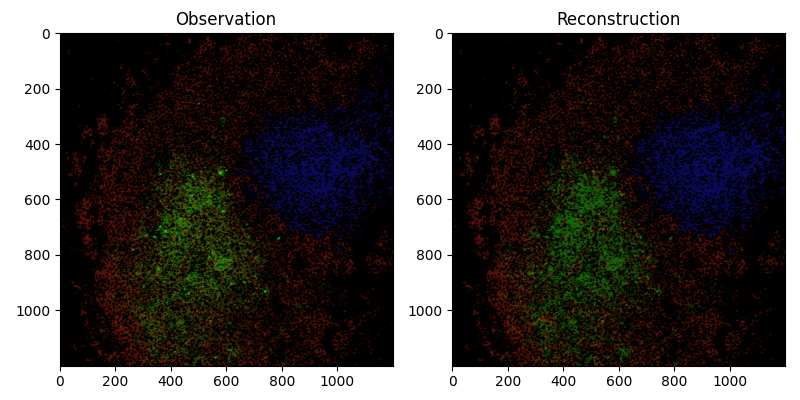

In [7]:
# -----------------------------
# 6. Reconstruction artifact and log tail from the selected completed inference
# -----------------------------
from IPython.display import Image as DisplayImage, display

if not RECONSTRUCTION_PATH.exists():
    raise FileNotFoundError(f"Expected reconstruction image not found: {RECONSTRUCTION_PATH}")

print("inference dir:", INFERENCE_RUN_DIR)
print("reconstruction image:", RECONSTRUCTION_PATH)
print("log:", INFERENCE_LOG_PATH)
if RESOURCE_USAGE_PATH is not None:
    print("latest resource usage csv:", RESOURCE_USAGE_PATH)

if INFERENCE_LOG_PATH.exists():
    log_lines = INFERENCE_LOG_PATH.read_text(errors="ignore").splitlines()
    print("\nLog tail")
    for line in log_lines[-12:]:
        print(line)

display(DisplayImage(filename=str(RECONSTRUCTION_PATH)))
